### 环境初始化

导入库

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import OptimizeResult
import matplotlib.pyplot as plt
import scienceplots

环境配置

In [2]:
plt.rcParams.update({"figure.dpi": "600"})
plt.style.use(["science", "high-vis"])

工具函数

In [3]:
def plot(sol: OptimizeResult, name: str, fmt: str = "pdf"):
    if len(sol.y) <= 1:
        plt.plot(sol.t, sol.y[0], label="x")
    else:
        for i, y in enumerate(sol.y):
            plt.plot(sol.t, y, label=f"$x_{i + 1}$")
        plt.legend()
    plt.xlabel("$t$")
    plt.ylabel("$x$")
    plt.savefig(f"../thesis/figures/{name}.{fmt}", format=fmt)
    plt.show()

## 基本生态学模型与通用模型

### Logistic 增长模型

$$
\frac{\mathrm{d} x}{\mathrm{d} t} = r x (1 - \frac{x}{k})
$$

In [4]:
logistic = lambda t, x, r, k: r * x * (1 - x / k)

In [5]:
t_span = [0, 10]
y0 = [3]
r = 1
k = 100

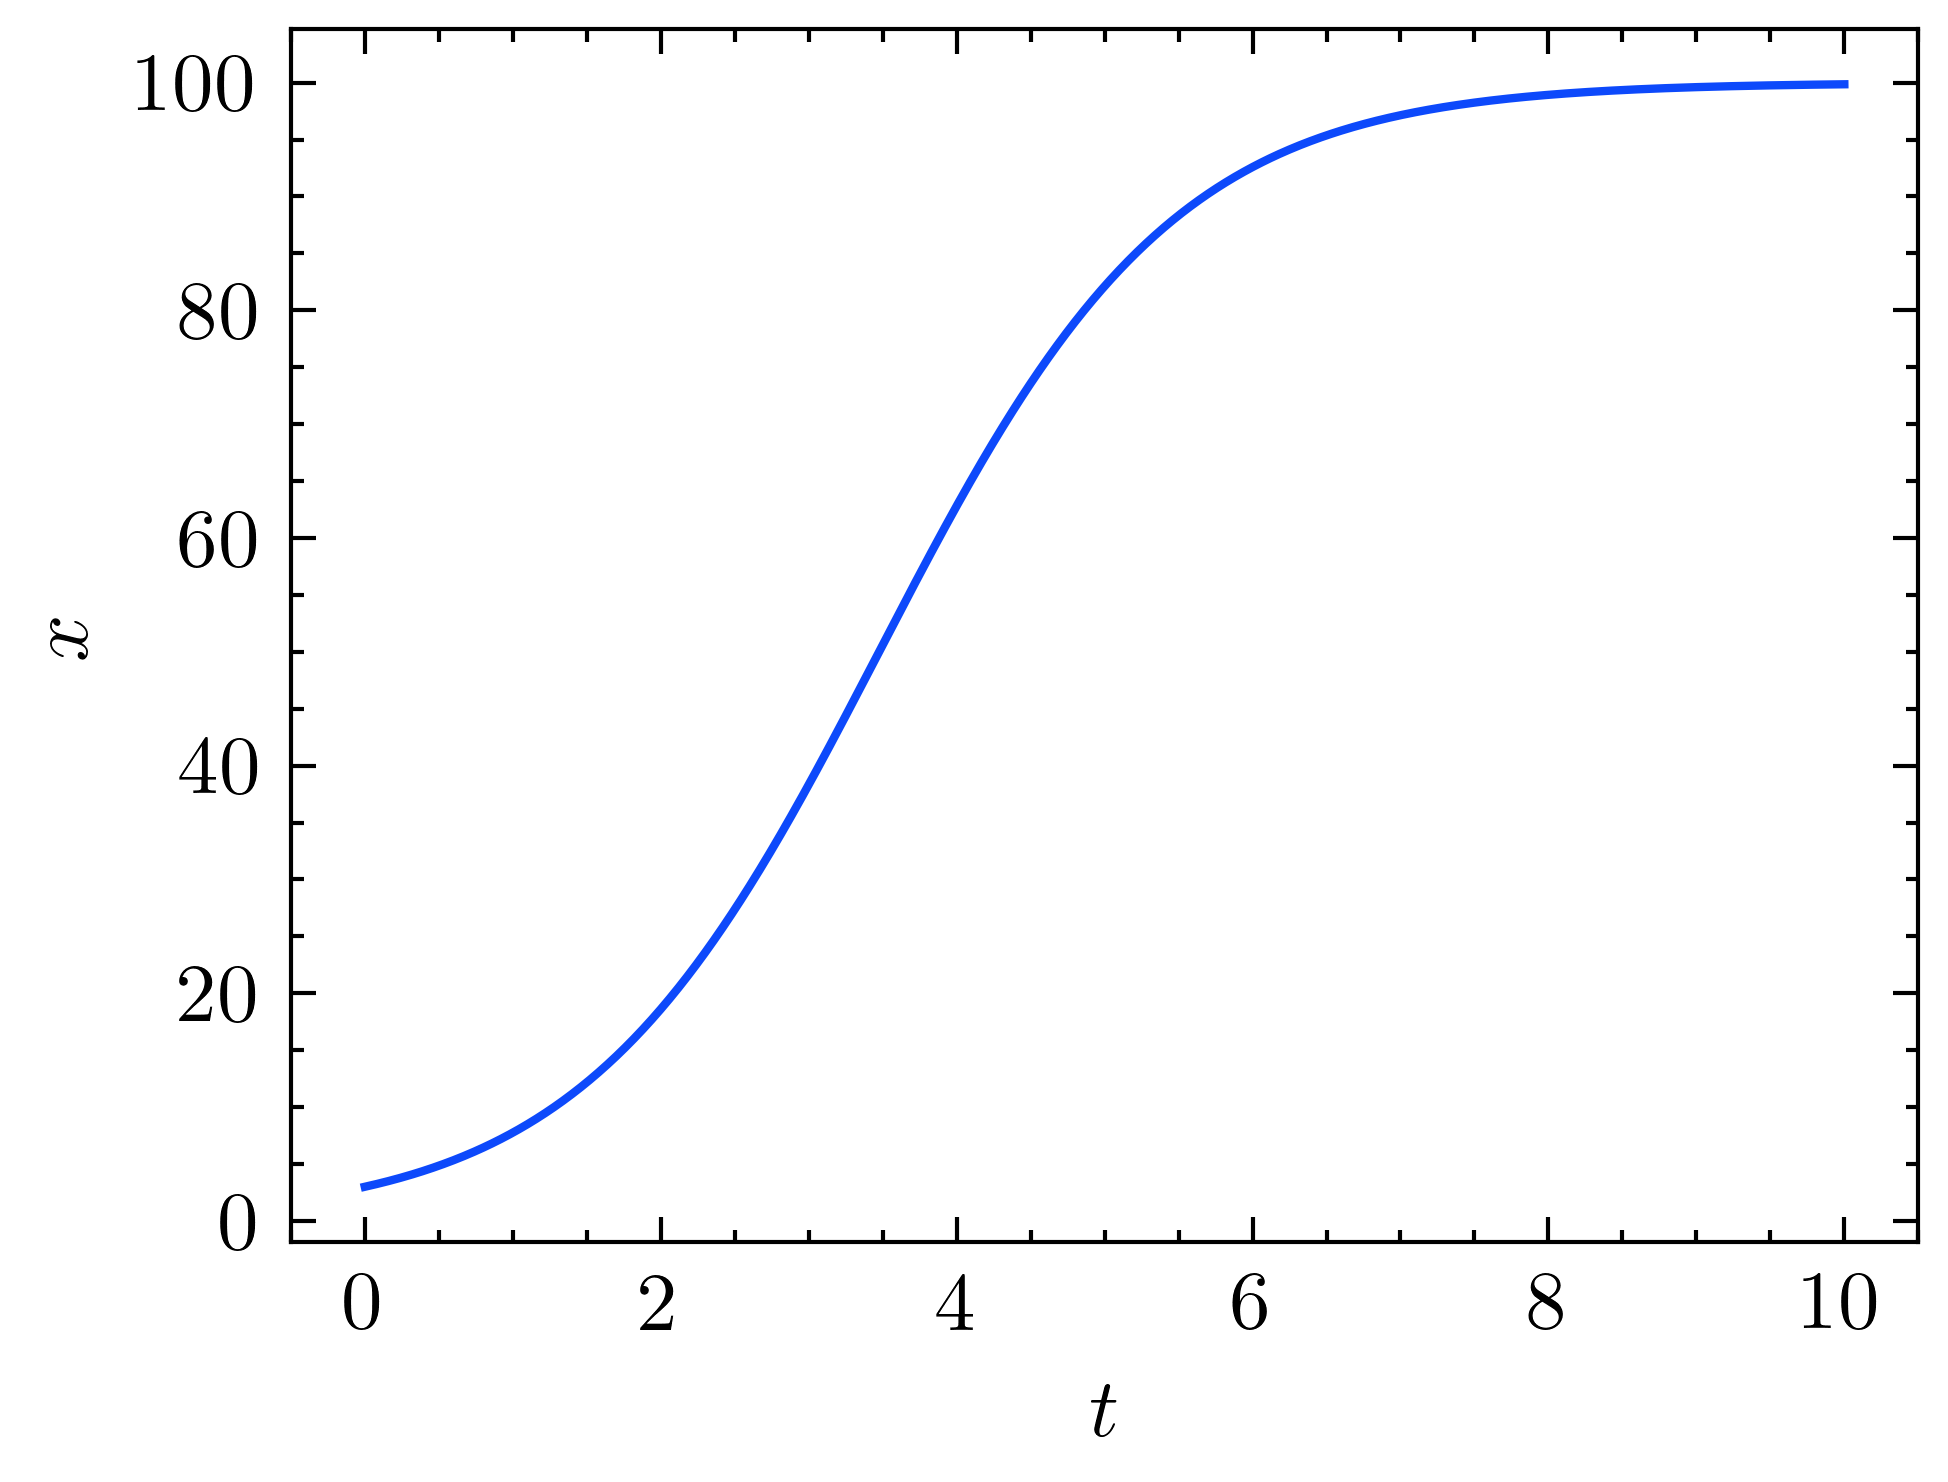

In [6]:
sol = solve_ivp(logistic, t_span, y0, args=(r, k), max_step=0.01)
plot(sol, "logistic")

### Lotka-Volterra 竞争模型

$$
\frac{\mathrm{d} x_1}{\mathrm{d} t} = r_1 x_1 (1 - \frac{x_1}{k_1} - \alpha_{1,2} \frac{x_2}{k_1})
$$
$$
\frac{\mathrm{d} x_2}{\mathrm{d} t} = r_2 x_2 (1 - \frac{x_2}{k_2} - \alpha_{2,1} \frac{x_1}{k_2})
$$

$$
\frac{\mathrm{d} x_i}{\mathrm{d} t} = r_i x_i (1 - \frac{1}{k_i} \sum_{j} \alpha_{i,j} x_j)
$$
$$
\frac{\mathrm{d} \mathbf{x}}{\mathrm{d} t} = \mathbf{x} \circ (\mathbf{I} - \boldsymbol{\alpha} \mathbf{x})
$$

In [7]:
lvc = lambda t, x, r, k, alpha: r * x * (1 - alpha @ x / k)

In [8]:
t_span = [0, 10]
y0 = [25, 50]
r = [1, 1]
k = [100, 150]
alpha = [
    [1, 2],
    [3, 1],
]

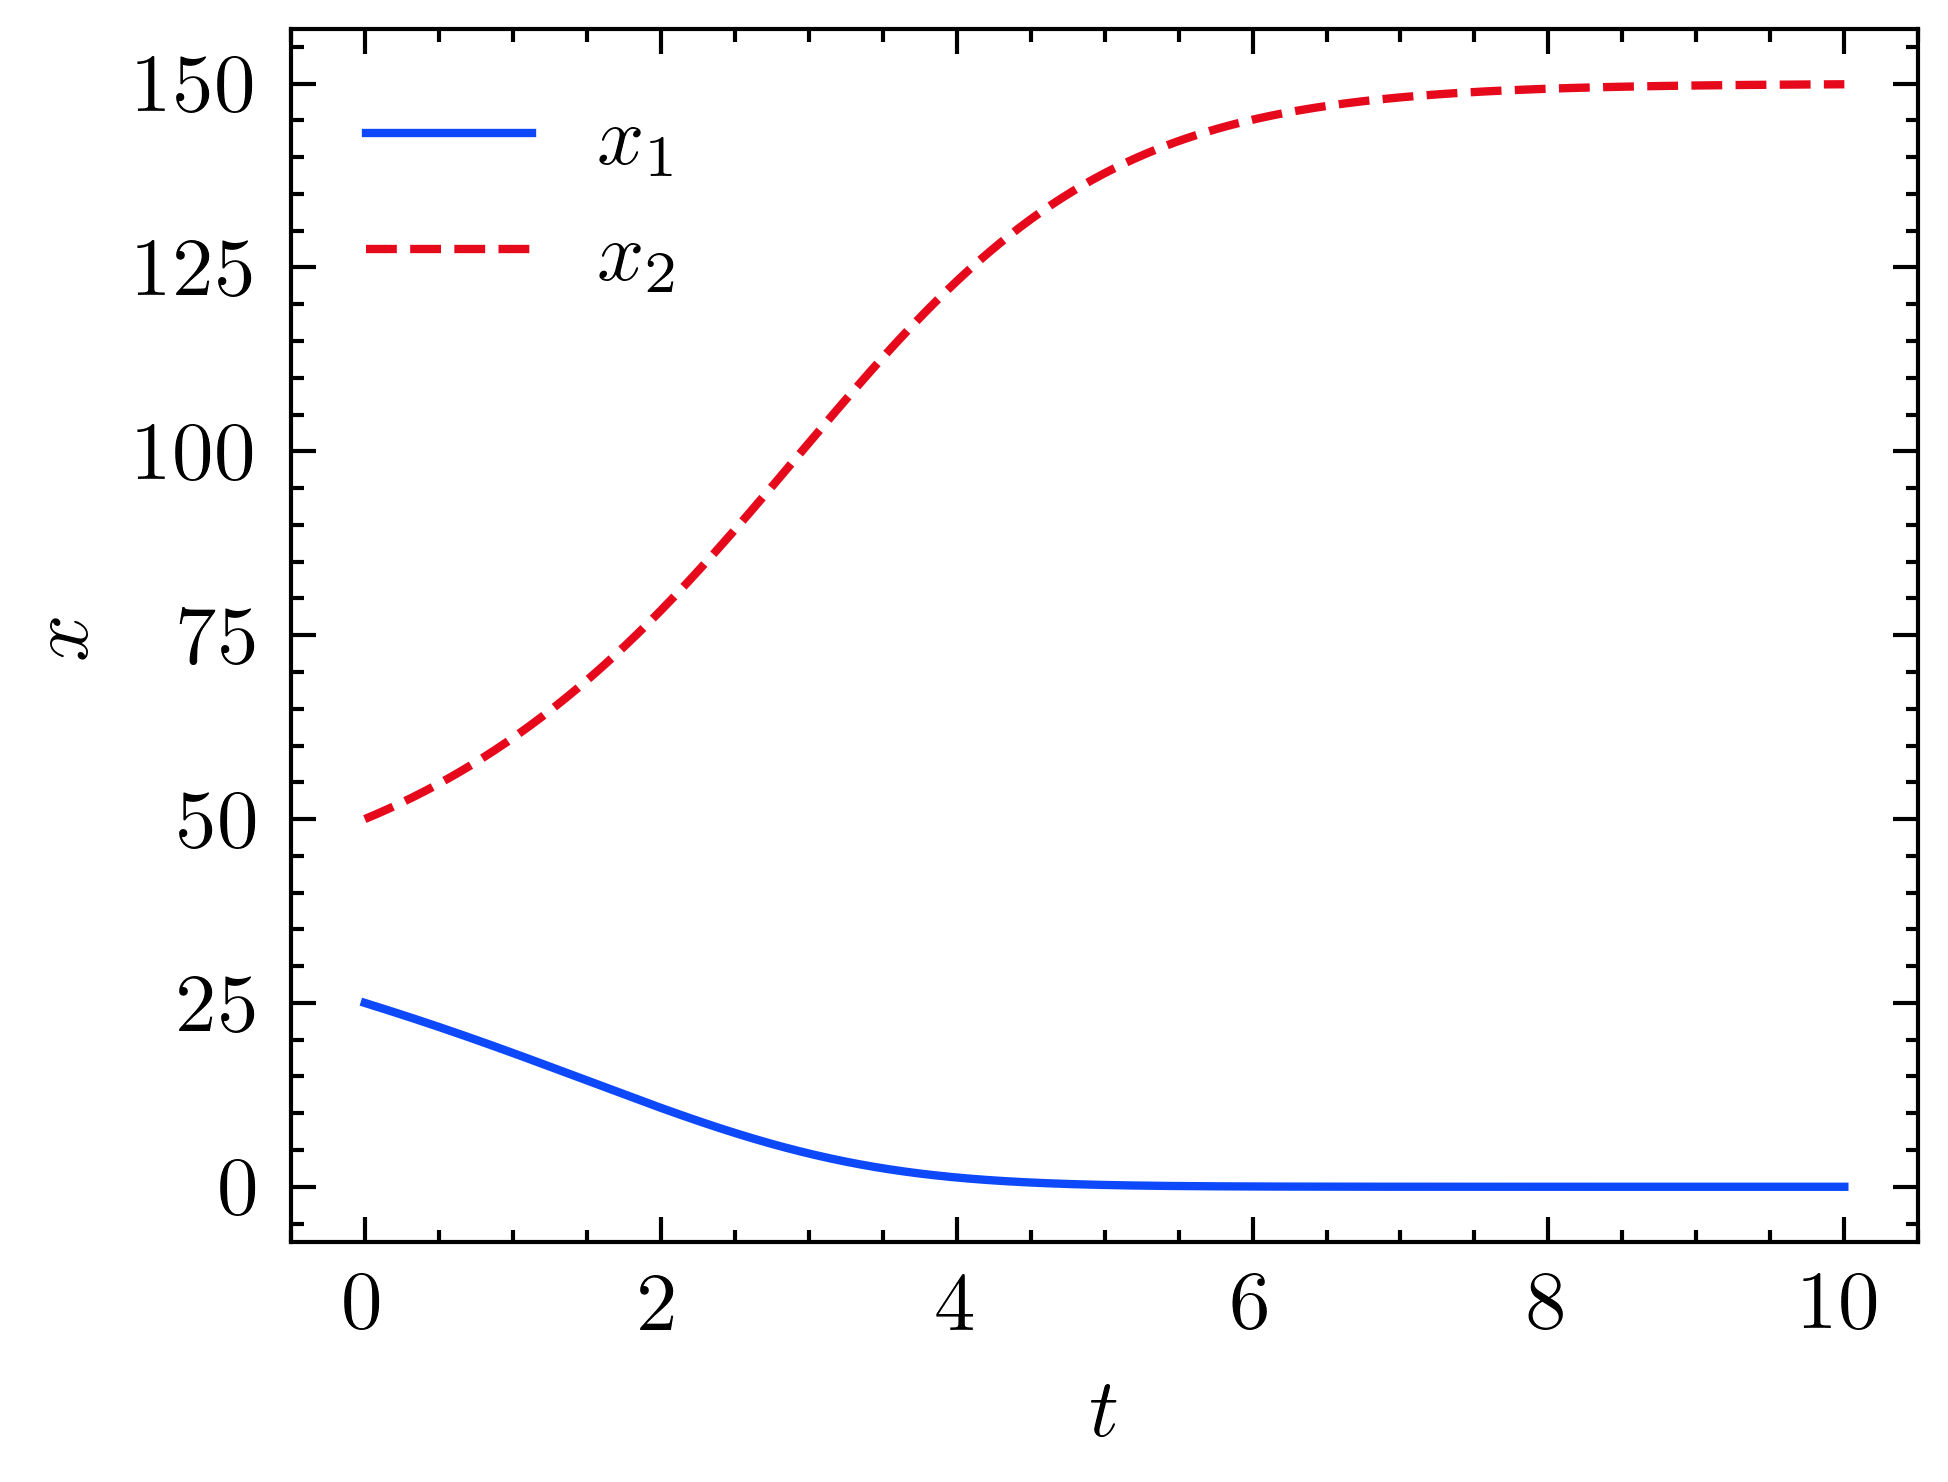

In [9]:
sol = solve_ivp(lvc, t_span, y0, args=(r, k, alpha), max_step=0.01)
plot(sol, "lotka-volterra-competition")

### Lotka-Volterra 捕食模型

$$
\frac{\mathrm{d} x_1}{\mathrm{d} t} = x_1 (r_1 - \beta_{1,2} x_2)
$$
$$
\frac{\mathrm{d} x_2}{\mathrm{d} t} = x_2 (-r_2 + \beta_{2,1} x_1)
$$

$$
\frac{\mathrm{d} x_i}{\mathrm{d} t} = x_i (r_i + \sum_{j} \beta_{i,j} x_j)
$$
$$
\frac{\mathrm{d} \mathbf{x}}{\mathrm{d} t} = \mathbf{x} \circ (\mathbf{r} + \boldsymbol{\beta} \mathbf{x})
$$

In [10]:
lvp = lambda t, x, r, beta: x * (r + beta @ x)

In [11]:
t_span = [0, 270]
y0 = [60, 20]
r = [0.07, -0.1]
beta = [
    [0, -0.001],
    [0.001, 0],
]

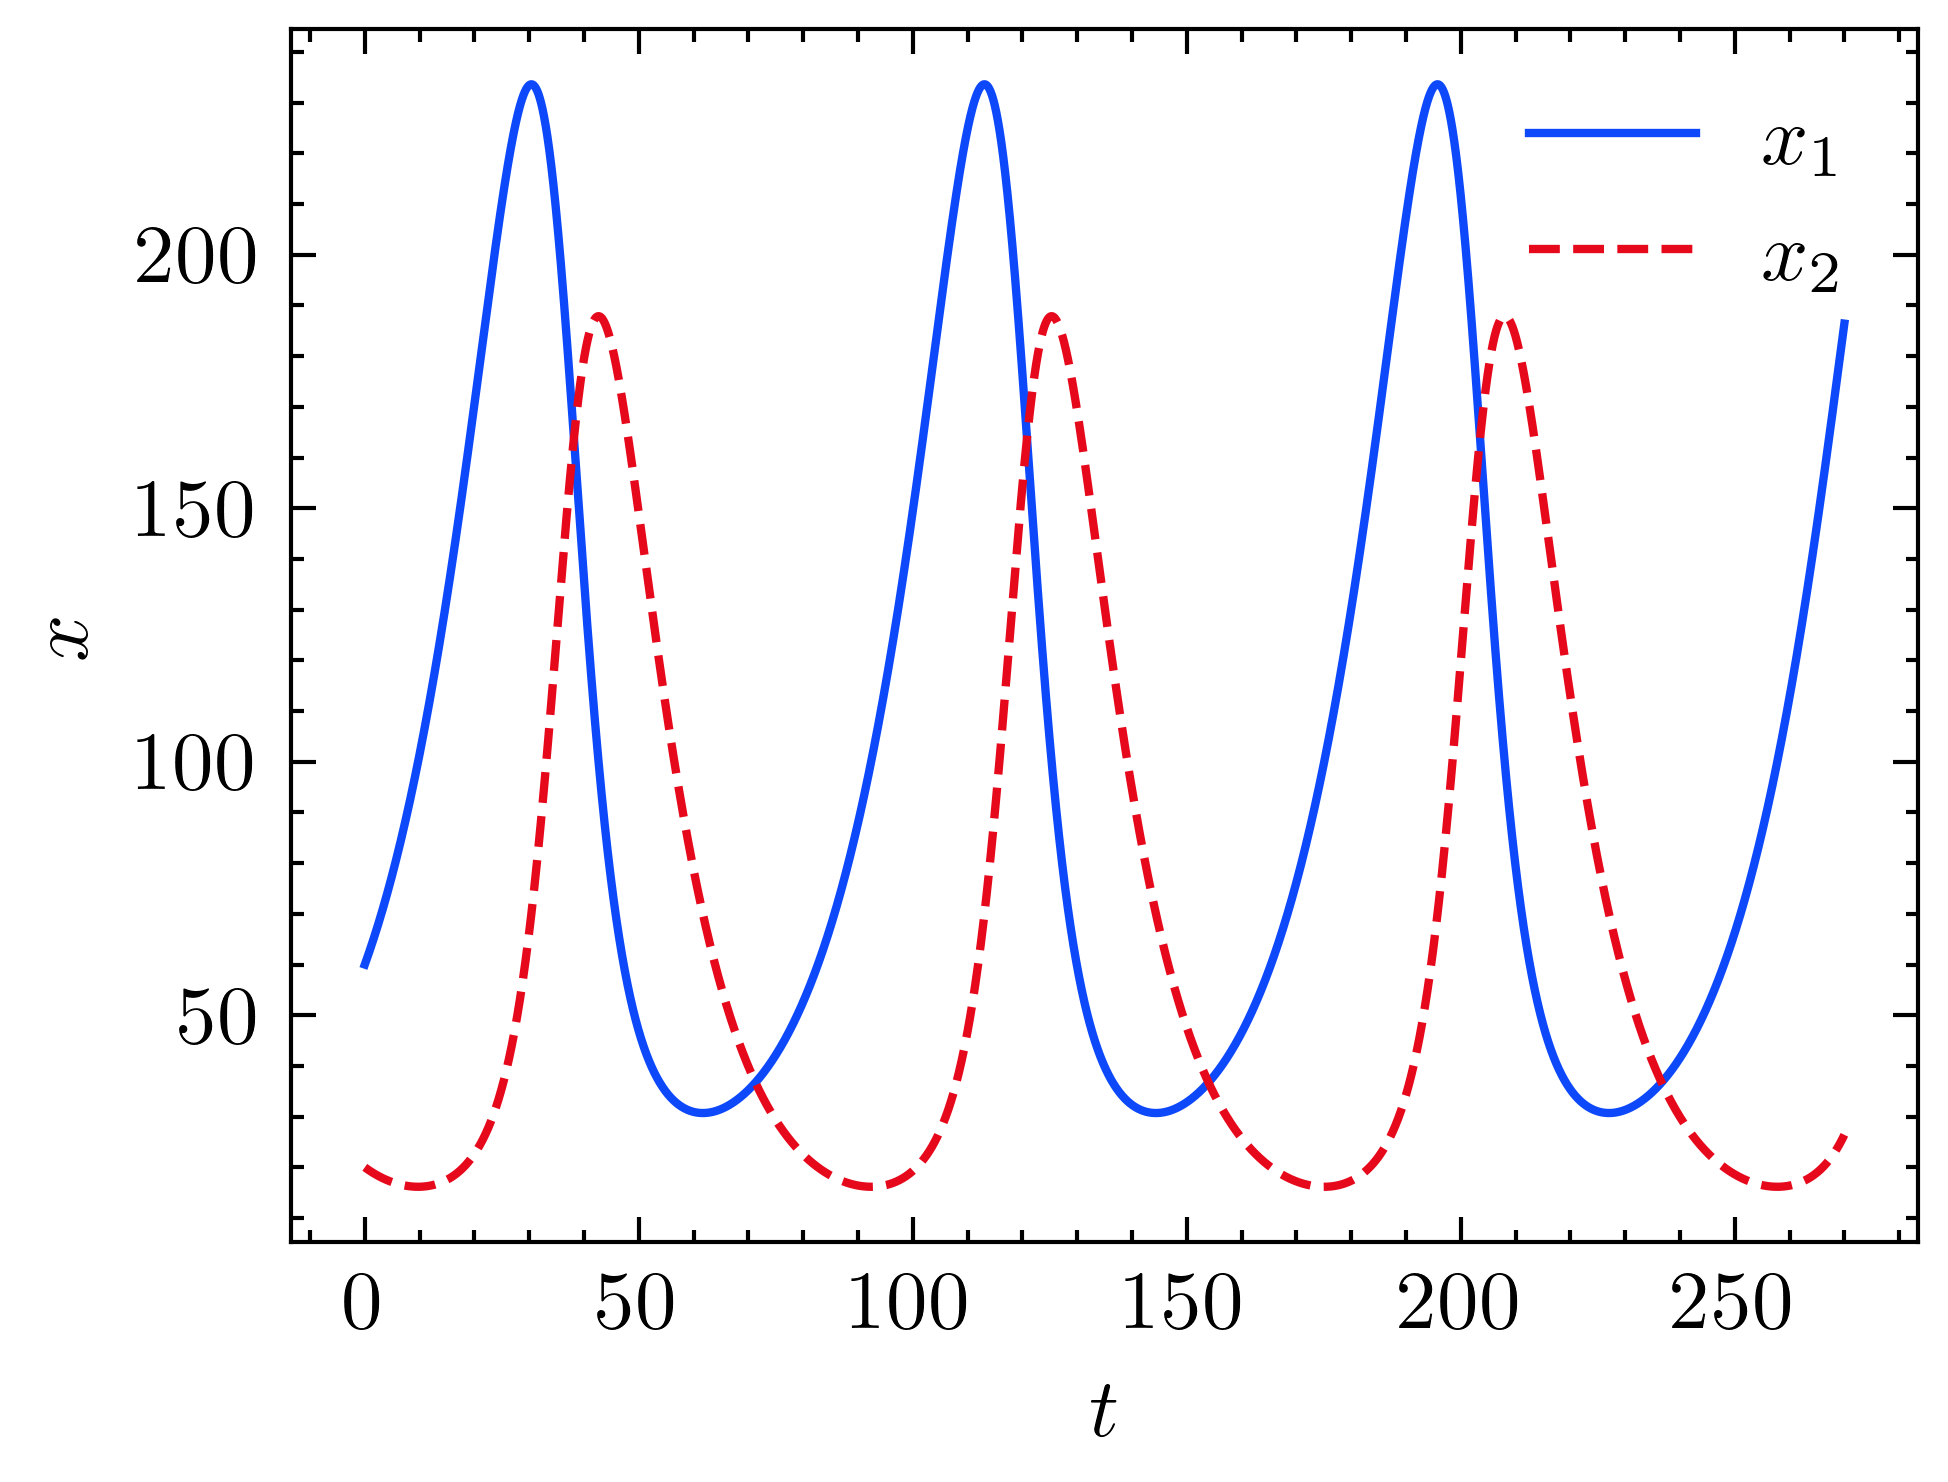

In [12]:
sol = solve_ivp(lvp, t_span, y0, args=(r, beta), max_step=0.01)
plot(sol, "lotka-volterra-predation")

### 正态分布

$$
f(x) = \frac{1}{\sigma \sqrt{2 \pi}} e^{-\frac{(x - \mu)^2}{2 \sigma^2}}
$$

In [13]:
norm = lambda mu, sig: lambda x: np.exp(-((x - mu) ** 2) / (2 * sig**2)) / (
    np.sqrt(2 * np.pi) * sig
)

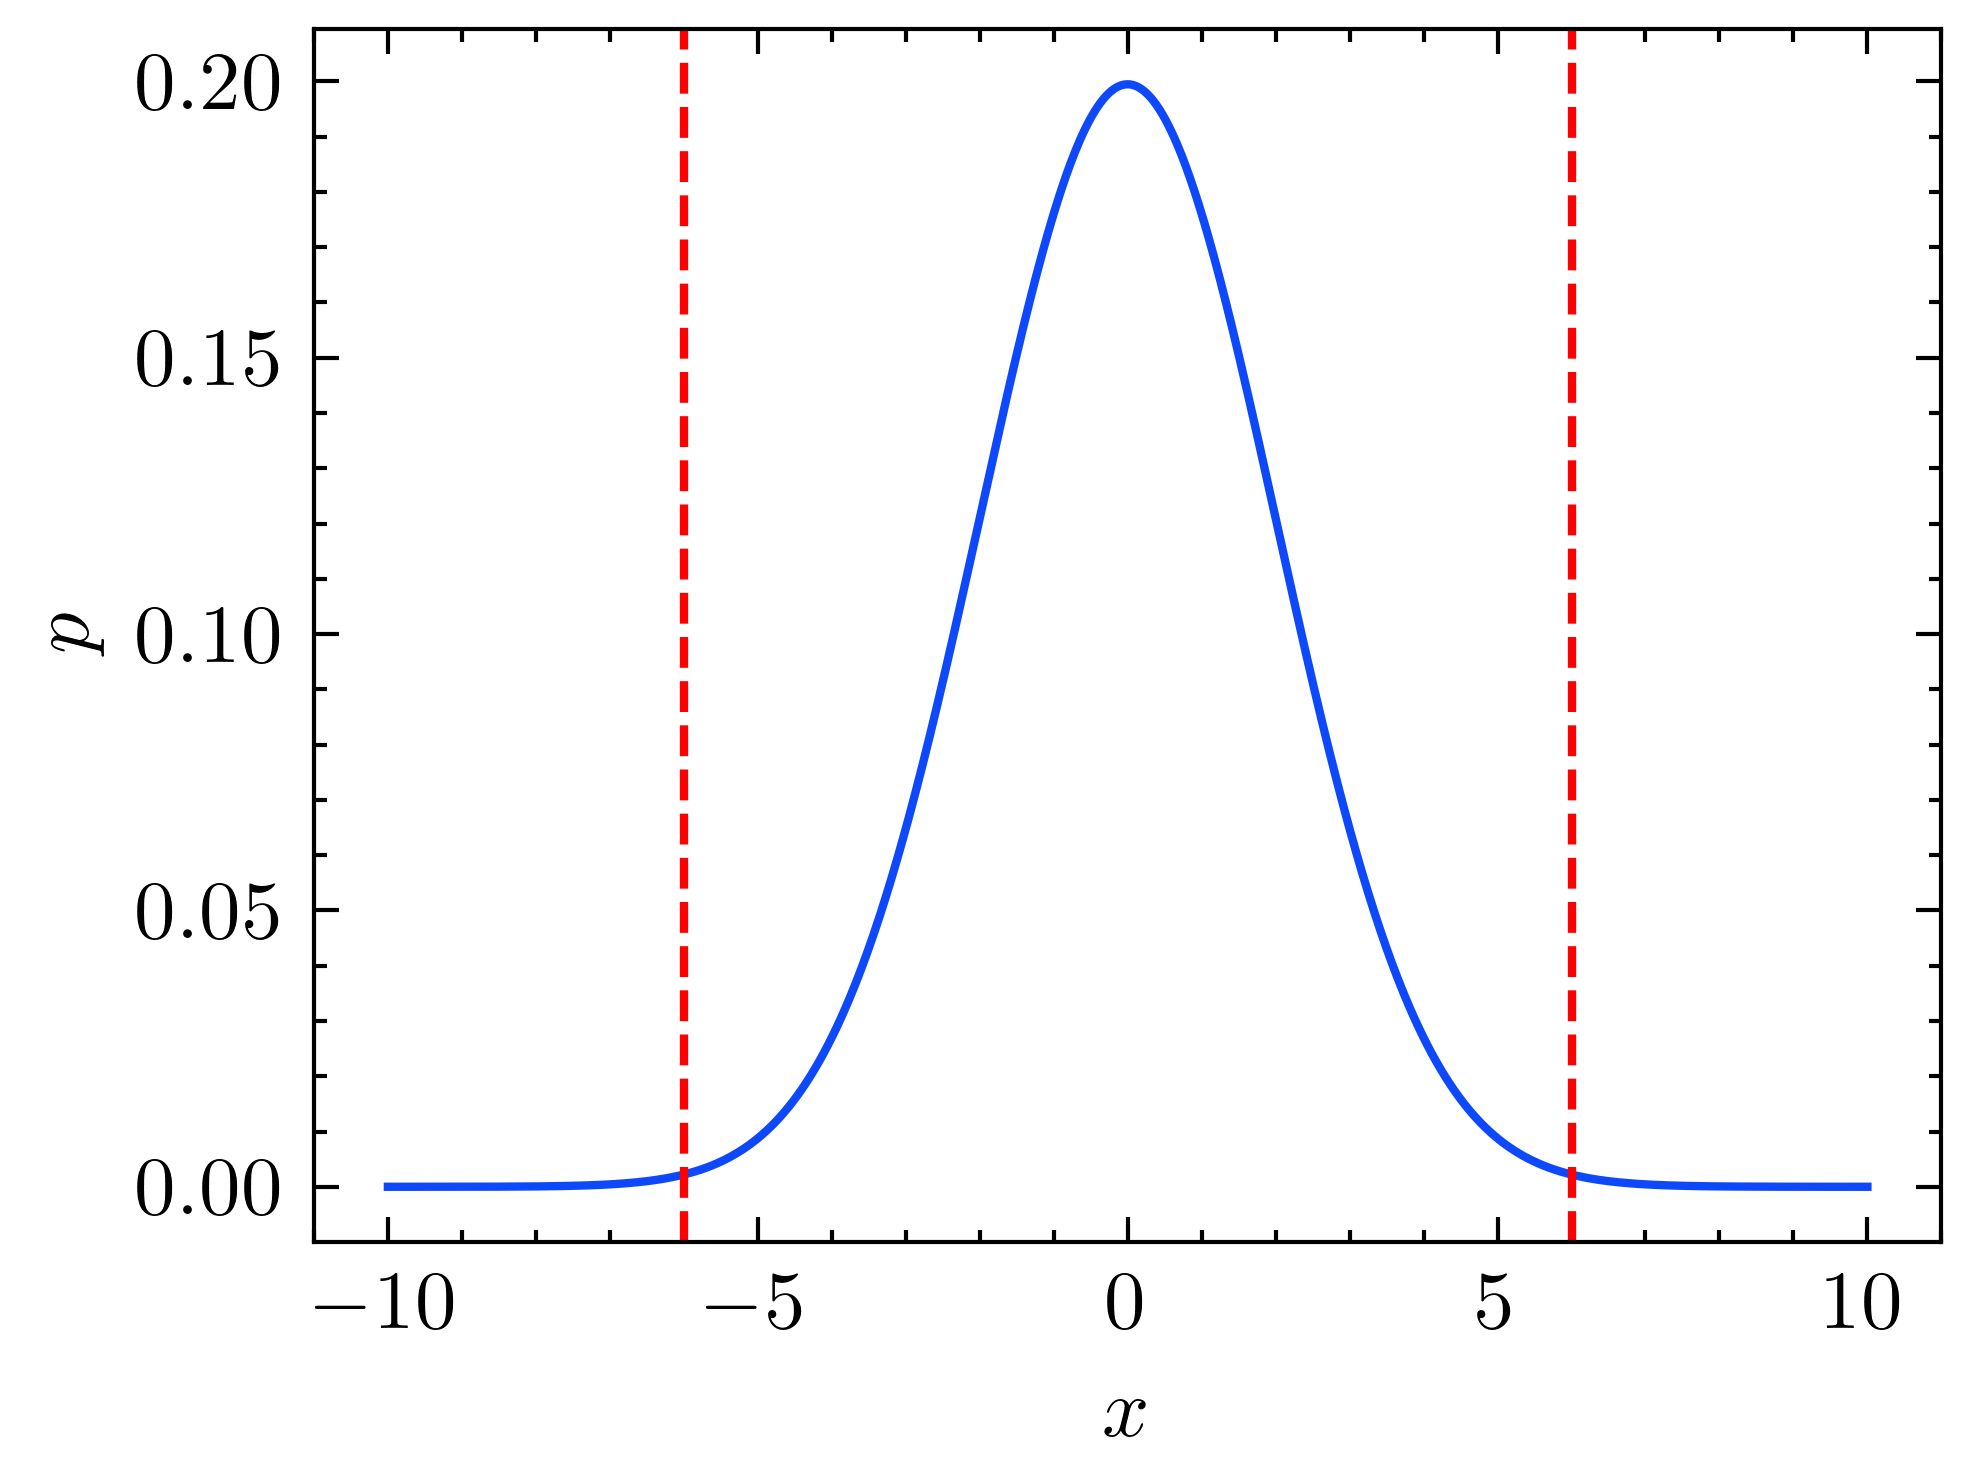

In [14]:
x_span = np.linspace(-10, 10, 1000)

plt.plot(x_span, norm(0, 2)(x_span), label="x")
plt.axvline(-6, color="r", linestyle="--")
plt.axvline(6, color="r", linestyle="--")
plt.xlabel("$x$")
plt.ylabel("$p$")
plt.savefig(f"../thesis/figures/normal-distribution.pdf", format="pdf")
plt.show()

### 综合模型

$$
\frac{\mathrm{d} x_i}{\mathrm{d} t} = x_i (1 - \frac{1}{k_i} \sum_{j} \alpha_{i,j} x_j) (r_i + \sum_{j} \beta_{i,j} x_j) + f_i(t)
$$
$$
\frac{\mathrm{d} \mathbf{x}}{\mathrm{d} t} = \mathbf{x} \circ (\mathbf{I} - \boldsymbol{\alpha} \mathbf{x}) \circ (\mathbf{r} + \boldsymbol{\beta} \mathbf{x}) + \mathbf{f}
$$

In [15]:
general = lambda t, x, r, k, alpha, beta, f: x * (1 - alpha @ x / k) * (r + beta @ x) + f(t)

In [16]:
t_span = [0, 1000]
y0 = [60, 20]
r = [0.09, -0.1]
k = [100, 150]
alpha = [
    [1, 2],
    [3, 1],
]
beta = [
    [0, -0.001],
    [0.001, 0],
]
f = lambda t: [np.random.normal()] * 2

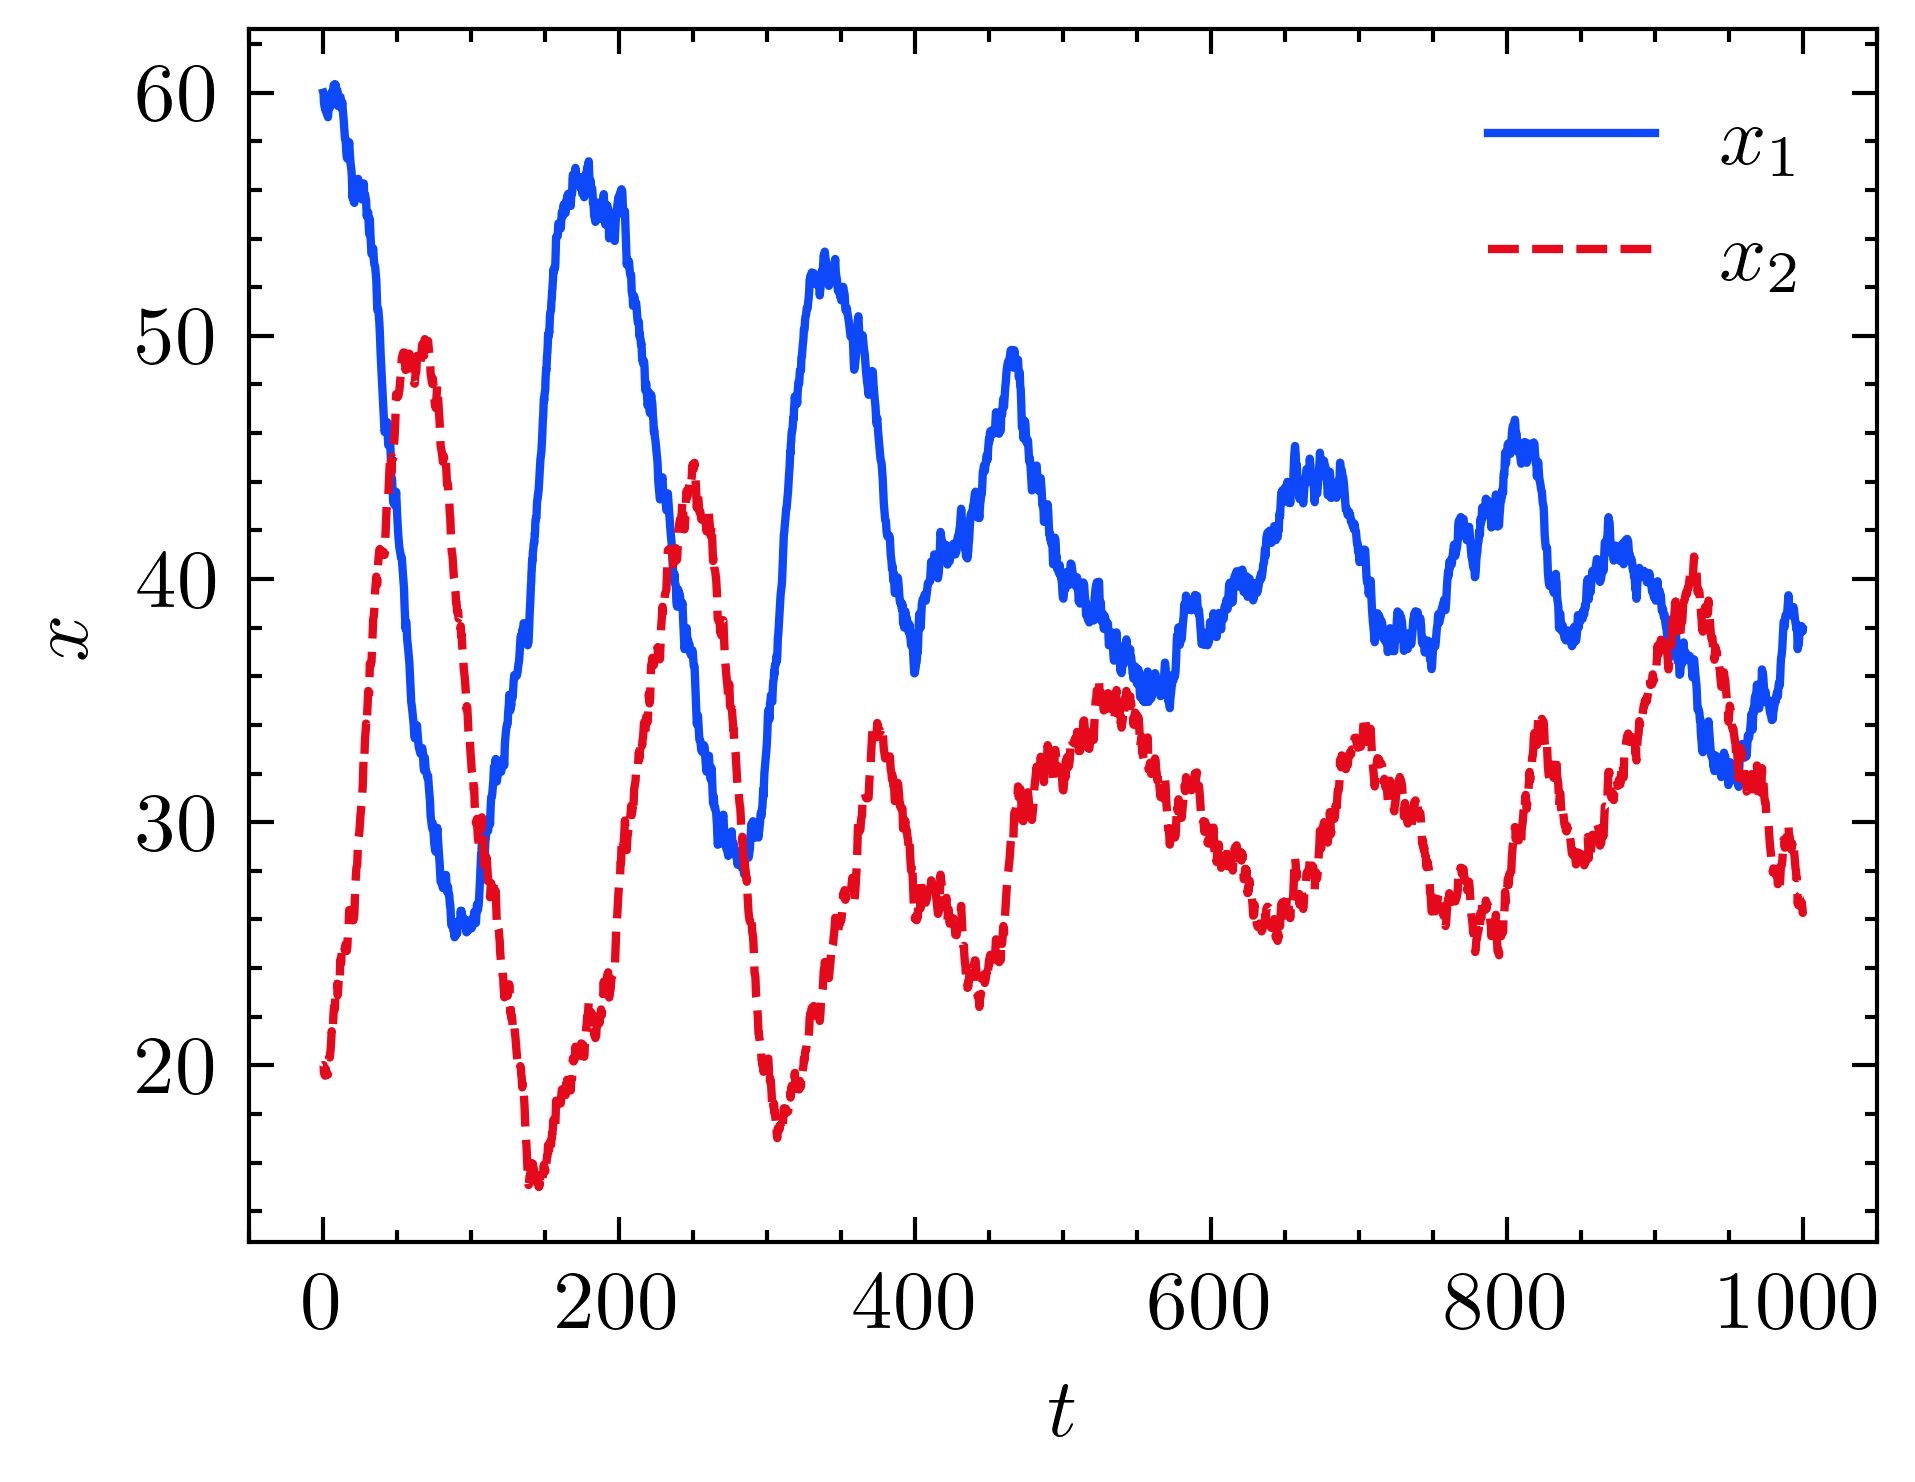

In [17]:
sol = solve_ivp(general, t_span, y0, args=(r, k, alpha, beta, f), max_step=1)
plot(sol, "general")

## 实例分析

### 稻蟹共生

In [ ]:
t_span = [0, 10]
y0 = [800, 2136, 1024, 1297, 355]
r = [1, 0.8, -0.3, -0.3, -0.6]
k = [5000, 3000, 2000, 3000, 500]
alpha = [
    [1, 1, 0, 0, 0],
    [2, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
]
beta = [
    [0, 0, -0.01, -0.001, 0],
    [0, 0, 0, -0.008, 0],
    [0, 0, 0, 0, -0.001],
    [0, 0, -0.008, 0, -0.001],
    [0, 0, 0, 0, 0],
]
f = lambda t: [np.random.normal(0, 3)] * 5

In [19]:
# sol = solve_ivp(general, t_span, y0, args=(r, k, alpha, beta, f), max_step=1)
# plot(sol, "rice-crab")